<a href="https://colab.research.google.com/github/YoshiakiHirayama/TangdaiMuzhiVectorAnalysis/blob/main/TangdaiMuzhiVectorAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SuPar-Kanbunを用いて(SK)解析を行い、単語について頻度分析(FA)をおこない、文ベクトルの解析と視覚化(SVAV)および単語ベクトルの解析と視覚化(WVAV)も行う。

（※文体としての美しさや優雅さ、故人の徳や功績の記述に力点を置いていた墓誌が、韓愈以降、作者と故人との思い出や日常の些細な出来事を描くようになったという変化は文ベクトルで表示可能なのではないか（浅尾））

〇文の単語切りには京大人文研・安岡孝一先生らが公開しておられるSuPar-Kanbunを用いる。SuPar-Kanbunは古典中国語Universal Dependencies（書写言語における品詞・形態素属性・依存構造を言語に依存せず記述する方法）を用いた文切り・形態素解析・係り受け解析のシステムである。なおSuPar-Kanbunでは品詞付与をTransformer4.0.1（以降）の系列ラベリングで実装しており、古典中国語UD（1文字単位）とroberta-classical-chinese-base-charで学習している。アウトプットは文脈依存ベクトルとして、768次元のベクトルで表現される。

Super-Kanbunをpipinstallする。なおエディターでプログラムを走らせる場合は、コマンドラインで実行する。

In [ ]:
# Super-Kanbunをpipinstall。
!pip install suparkanbun

ファイルの入出力を伴うので、Google Driveをマウントする。

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Super-Kanbunをインポートする。

In [ ]:
import suparkanbun
nlp=suparkanbun.load(BERT="roberta-classical-chinese-base-char",Danku=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


filesize.txt:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

suparkanbun/models/roberta-classical-chi(…):   0%|          | 0.00/423M [00:00<?, ?B/s]

suparkanbun/models/roberta-classical-chi(…):   0%|          | 0.00/473M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/428M [00:00<?, ?B/s]

filesize.txt:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

suparkanbun/models/roberta-classical-chi(…):   0%|          | 0.00/423M [00:00<?, ?B/s]

テキストファイルを指定して解析を行う。テキストファイルは韓愈の墓誌を集成したもので、中國哲學書電子化計劃において公開されている韓愈撰/朱熹考異『朱文公校昌黎先生文集』をベースに劉真倫・岳珍校注『韓愈文集彙校箋注』（中華書局、2023）に従って校勘を行い誤字も修正したもの。なお、今後の解析にそなえて、頻度分析や共起分析に適した形で結果をアウトプットするように指定している。

In [ ]:
input_file = "/content/drive/My Drive/hm_input.csv"
output_file = "/content/drive/My Drive/hm_output_tokens.csv"

#input_file = "/content/drive/My Drive/20251226.csv"
#output_file = "/content/drive/My Drive/20251226_output.csv"

# テキストファイルの読み込み
with open(input_file, "r", encoding="utf-8") as fin, \
     open(output_file, "w", encoding="utf-8") as fout:
    for line in fin:
        line = line.strip()  # 前後の空白や改行を削除
        if not line:  # 空行をスキップ
            continue

        # 漢文解析の実施
        doc = nlp(line)

        # トークン化（1文字ずつ）
        # nlp(line)の結果からトークンのテキストを抽出
        tokens = [token.text for token in doc]

        # スペース区切りで保存
        fout.write(" ".join(tokens) + "\n")

INFO:supar:Loading the data
INFO:supar:
Dataset(n_sentences=46, n_batches=8, n_buckets=8)
INFO:supar:Making predictions on the dataset
INFO:supar:0:00:02.719969s elapsed, 16.91 Sents/s
INFO:supar:Loading the data
INFO:supar:
Dataset(n_sentences=38, n_batches=8, n_buckets=8)
INFO:supar:Making predictions on the dataset
INFO:supar:0:00:01.645664s elapsed, 23.09 Sents/s
INFO:supar:Loading the data
INFO:supar:
Dataset(n_sentences=69, n_batches=8, n_buckets=8)
INFO:supar:Making predictions on the dataset
INFO:supar:0:00:02.340913s elapsed, 29.48 Sents/s
INFO:supar:Loading the data
INFO:supar:
Dataset(n_sentences=71, n_batches=8, n_buckets=8)
INFO:supar:Making predictions on the dataset
INFO:supar:0:00:03.410744s elapsed, 20.82 Sents/s
INFO:supar:Loading the data
INFO:supar:
Dataset(n_sentences=64, n_batches=8, n_buckets=8)
INFO:supar:Making predictions on the dataset
INFO:supar:0:00:02.785919s elapsed, 22.97 Sents/s
INFO:supar:Loading the data
INFO:supar:
Dataset(n_sentences=32, n_batches=8

〇出力したデータの頻度分析を実施する。トークン化済みデータを読み込み、すべての個別トークンを抽出し、各ユニークなトークンの出現頻度を数え、最も頻繁に出現するトークンを示す棒グラフを作成し、最後にトークン頻度分析の結果と可視化から得られる洞察をまとめる。

出力ファイルからトークン化済みデータを読み込む。


In [ ]:
tokenized_lines = []
with open(output_file, "r", encoding="utf-8") as f:
    for line in f:
        tokenized_lines.append(line.strip())

#print(f"Loaded {len(tokenized_lines)} lines from {output_file}")
#print("First 5 lines:")
#for i, line in enumerate(tokenized_lines[:5]):
    #print(f"Line {i+1}: {line}")

読み込んだトークン化済みデータから すべてのトークンを1つのリストにまとめ、各トークンの出現頻度を数え上げる。

In [ ]:
from collections import Counter

# すべてのトークンを1つのリストにまとめる
all_tokens = []
for line in tokenized_lines:
    # 各行のトークンはスペース区切りと仮定
    tokens = line.split()
    all_tokens.extend(tokens)

# 各トークンの出現頻度をカウント
token_counts = Counter(all_tokens)

# 上位 n 個のトークンを表示
top_n = 200
print(f"Top {top_n} most frequent tokens:")
for token, count in token_counts.most_common(top_n):
    print(f"{token}: {count}")

Top 200 most frequent tokens:
之: 55
人: 50
夫: 49
其: 47
以: 36
年: 33
於: 31
為: 29
氏: 26
有: 26
不: 24
子: 23
父: 20
卒: 20
女: 20
曰: 18
公: 16
月: 16
銘: 16
日: 15
大: 14
母: 14
愈: 14
書: 13
州: 13
葬: 13
婦: 13
諱: 12
事: 12
二: 12
史: 11
三: 11
而: 11
生: 11
韓: 11
太: 10
中: 10
法: 10
與: 10
在: 10
河南: 9
歸: 9
某: 9
男: 9
嫁: 9
家: 9
祖: 8
門: 8
令: 8
守: 8
軍: 8
教: 8
四: 8
曹: 8
者: 8
莫: 8
贈: 7
郎: 7
司: 7
御: 7
言: 7
一: 7
所: 7
先: 7
從: 7
元和: 7
外: 7
國: 7
孫: 7
士: 7
世: 6
率: 6
王: 6
左: 6
時: 6
能: 6
失: 6
又: 6
姑: 6
九: 6
宗: 6
節: 6
妻: 6
參: 6
成: 6
尚: 6
開封: 6
七: 5
封: 5
後: 5
相: 5
官: 5
曾: 5
少: 5
我: 5
若: 5
干: 5
道: 5
府: 5
況: 5
族: 5
是: 5
盧: 5
尊: 5
德: 5
既: 5
苗: 5
墓: 5
姓: 4
上: 4
自: 4
都: 4
馬: 4
刺: 4
娶: 4
得: 4
及: 4
累: 4
明: 4
五: 4
聞: 4
使: 4
可: 4
至: 4
疾: 4
乃: 4
治: 4
惟: 4
天: 4
婉: 4
承: 4
宜: 4
入: 4
長: 4
友: 4
來: 4
十一: 4
周: 4
行: 4
或: 4
繼: 3
顯: 3
僕: 3
射: 3
皋: 3
卿: 3
愛: 3
選: 3
今: 3
始: 3
遂: 3
第: 3
受: 3
賢: 3
良: 3
皆: 3
十: 3
爰: 3
親: 3
赫: 3
唐: 3
貞元: 3
十五: 3
李: 3
南: 3
晉: 3
戡: 3
肅: 3
乞: 3
易: 3
侯: 3
貴: 3
厥: 3
聲: 3
克: 3
司徒: 3
侍: 3
部: 3
初: 3
齊: 3
內: 3
然: 3
賀: 3
常: 3
嘗: 

可視化する際に漢字が正しく表示されるようにフォントを明示的にインストールする

In [ ]:
# フォントをインストール（Colab / Ubuntu）
!apt-get -y install fonts-wqy-zenhei

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# フォントファイルのパス
font_path = "/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc"

# フォントをMatplotlibに追加
fm.fontManager.addfont(font_path)

# グラフ上で漢字が文字化けすることを防ぐためォント名を明示的に指定
plt.rcParams["font.family"] = "WenQuanYi Zen Hei"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-wqy-zenhei
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 7,472 kB of archives.
After this operation, 16.8 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-wqy-zenhei all 0.9.45-8 [7,472 kB]
Fetched 7,472 kB in 1s (7,276 kB/s)
Selecting previously unselected package fonts-wqy-zenhei.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../fonts-wqy-zenhei_0.9.45-8_all.deb ...
Unpacking fonts-wqy-zenhei (0.9.45-8) ...
Setting up fonts-wqy-zenhei (0.9.45-8) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


棒グラフで頻出トークンを可視化する。

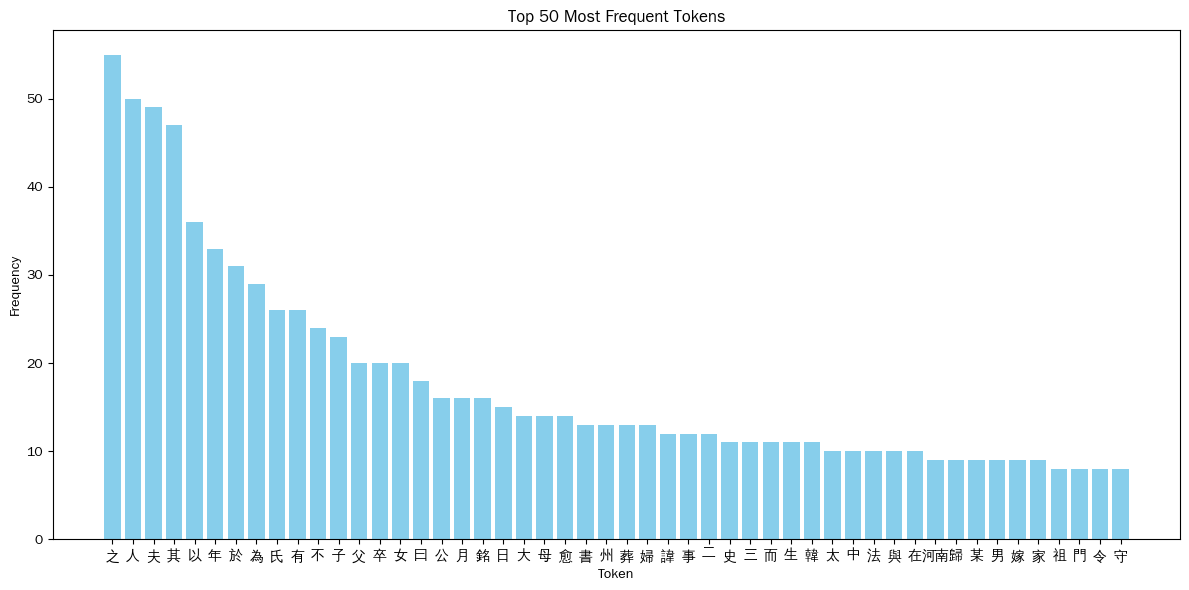

In [ ]:
import matplotlib.pyplot as plt

# 上位 n 個のトークンを表示する
top_n = 50
most_common_tokens = token_counts.most_common(top_n)
tokens, counts = zip(*most_common_tokens)  # トークンとカウントに分ける

# 棒グラフを作成
plt.figure(figsize=(12, 6))
plt.bar(tokens, counts, color="skyblue")
#plt.xticks(rotation=45, ha="right")
# x軸ラベルを斜めにして読みやすく→chatgptの余計なお世話だったので無効化
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.title(f"Top {top_n} Most Frequent Tokens")
plt.tight_layout()  # ラベルが切れないように調整
plt.show()

解析結果に基づき、確認したいトークンの文脈を確認できるようにする。

In [ ]:
SPECIFIC_TOKEN = "大" # 表示したい特定のトークンを入力
NUM_EXAMPLES = 100    # 表示したい文脈例の数を入力
CONTEXT_WINDOW = 10  # 表示したい前後の文字数を入力

print(f"\n特定のトークン '{SPECIFIC_TOKEN}' の詳細な文脈例（上位 {NUM_EXAMPLES} 件）:\n")

# Re-collect all doc_tokens by processing *each original line* from the input file
doc_tokens = []
with open(input_file, "r", encoding="utf-8") as fin:
    for line_content in fin:
        line_stripped = line_content.strip()
        if not line_stripped:
            continue

        doc_for_this_line = nlp(line_stripped)
        full_line_text = "".join(t.text for t in doc_for_this_line) # Context for this line

        offset = 0
        for t in doc_for_this_line:
            start = offset
            end = offset + len(t.text)
            offset = end

            doc_tokens.append({
                "form": t.text,
                "upos": t.pos_,
                "xpos": t.tag_,
                "text": full_line_text, # Assign the full line text as context
                "start": start,
                "end": end
            })

# 指定されたトークンの出現箇所をフィルタリング
instances_of_specific_token = [t_info for t_info in doc_tokens if t_info["form"] == SPECIFIC_TOKEN]

if not instances_of_specific_token:
    print(f"'{SPECIFIC_TOKEN}' は見つかりませんでした。")
else:
    for i, inst in enumerate(instances_of_specific_token[:NUM_EXAMPLES]):
        text = inst["text"]

        s = max(0, inst["start"] - CONTEXT_WINDOW)
        e = min(len(text), inst["end"] + CONTEXT_WINDOW)

        context = (
            text[s:inst["start"]] +
            "[" + SPECIFIC_TOKEN + "]" +
            text[inst["end"]:e]
        )
        print(f"例 {i+1}:")
        print(f"  品詞: {inst['upos']} / {inst['xpos']}")
        print(f"  文脈: {context}\n")


特定のトークン '大' の詳細な文脈例（上位 100 件）:



INFO:supar:Loading the data
INFO:supar:
Dataset(n_sentences=46, n_batches=8, n_buckets=8)
INFO:supar:Making predictions on the dataset
INFO:supar:0:00:03.833224s elapsed, 12.00 Sents/s
INFO:supar:Loading the data
INFO:supar:
Dataset(n_sentences=38, n_batches=8, n_buckets=8)
INFO:supar:Making predictions on the dataset
INFO:supar:0:00:03.435833s elapsed, 11.06 Sents/s
INFO:supar:Loading the data
INFO:supar:
Dataset(n_sentences=69, n_batches=8, n_buckets=8)
INFO:supar:Making predictions on the dataset
INFO:supar:0:00:04.400826s elapsed, 15.68 Sents/s
INFO:supar:Loading the data
INFO:supar:
Dataset(n_sentences=71, n_batches=8, n_buckets=8)
INFO:supar:Making predictions on the dataset
INFO:supar:0:00:05.632820s elapsed, 12.60 Sents/s
INFO:supar:Loading the data
INFO:supar:
Dataset(n_sentences=64, n_batches=8, n_buckets=8)
INFO:supar:Making predictions on the dataset
INFO:supar:0:00:04.611080s elapsed, 13.88 Sents/s
INFO:supar:Loading the data
INFO:supar:
Dataset(n_sentences=32, n_batches=8

例 1:
  品詞: VERB / v,動詞,描写,量
  文脈: 留守北都卒贈秘書監其[大]王父迢以都官郎為嶺南

例 2:
  品詞: VERB / v,動詞,描写,量
  文脈: 十五年靈州節度使御史[大]夫李公諱欒守邊有勞詔

例 3:
  品詞: VERB / v,動詞,描写,量
  文脈: 家難甚吏治又況公侯族[大]而貴夫人是專厥聲惟懿

例 4:
  品詞: VERB / v,動詞,描写,量
  文脈: 淑哉夫人夙有多譽來嬪[大]家不介母父有事賓祭酒

例 5:
  品詞: VERB / v,動詞,描写,量
  文脈: 事亦莫有施齊其躬心小[大]順之夫先其歸其室有丘

例 6:
  品詞: VERB / v,動詞,描写,量
  文脈: 夫人姓翟氏故檢校御史[大]夫宋州刺史良佐之女今

例 7:
  品詞: VERB / v,動詞,描写,量
  文脈: 節度使散騎常待兼御史[大]夫公武之母夫人在家以

例 8:
  品詞: VERB / v,動詞,描写,量
  文脈: 所宜歸以適韓氏韓氏族[大]且貴又太尉劉公甥內外

例 9:
  品詞: VERB / v,動詞,描写,量
  文脈: 不危溢者楚國有助焉耳[大]夫領梁偏師卒就蔡功受

例 10:
  品詞: VERB / v,動詞,描写,量
  文脈: 薨於鄜之公府春秋若干[大]夫委節去位奉喪以居東

例 11:
  品詞: VERB / v,動詞,描写,量
  文脈: 卒贈尚書主客郎中其次[大]夫公武也銘曰翟氏之先

例 12:
  品詞: VERB / v,動詞,描写,量
  文脈: 夫人太守之子司徒之妻[大]夫之母公居河東子在鄜

例 13:
  品詞: VERB / v,動詞,描写,量
  文脈: 苗氏諱某字某上黨人曾[大]父襲夔贈禮部尚書大父

例 14:
  品詞: VERB / v,動詞,描写,量
  文脈: 曾大父襲夔贈禮部尚書[大]父殆庶贈太子太師父如



〇文ベクトルを求めて可視化をおこなう。文ベクトルの導出はSuPar-Kanbunの内部で行われる。

※文ベクトルを求める過程に関してさらに理解が必要

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    "KoichiYasuoka/roberta-classical-chinese-base-char"
)
model = AutoModel.from_pretrained(
    "KoichiYasuoka/roberta-classical-chinese-base-char"
)

model.eval()


RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(26318, 768, padding_idx=1)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dr

In [ ]:
sentence_vectors = []
sentences = []  # 表示用

with torch.no_grad():
    for line in tokenized_lines:
        if not line:
            continue

        tokens = line.split()

        inputs = tokenizer(
            tokens,
            is_split_into_words=True,
            return_tensors="pt",
            truncation=True
        )

        outputs = model(**inputs)

        # Superkanbunでも [CLS] を文ベクトルとして使用
        cls_vector = outputs.last_hidden_state[:, 0, :]
        sentence_vectors.append(cls_vector.squeeze().numpy())

        # 表示用に元文へ戻す
        sentences.append("".join(tokens))


In [ ]:
X = np.array(sentence_vectors)
print("Vector shape:", X.shape)

Vector shape: (9, 768)


SuPar-Kanbunの文章ベクトルは、Transformerに由来することから768次元のベクトルとして出力される。人間がこれを直観的に把握することは困難なため、主成分分析を行う。主成分分析（PCA分析）は相関のある多数の変数から、相関のない少数で全体のばらつきを最もよく表す主成分と呼ばれる変数を合成する多変量解析の一手法である。データの次元を削減するために用いられる。第一主成分の分散を最大化し、続く主成分はそれまでに決定した主成分と直交するという拘束条件の下で分散を最大化するようにして選ばれる。選ばれた主成分は互いに直交し、与えられた観測値のセットを線型結合として表すことができる。すなわち、選ばれたn個の主成分のn次元マップとして視覚化できる。ただし、あくまでも視覚化が可能なだけであり、選ばれた主成分の「意味」を考えることは人間に委任されている。なお、主成分分析の評価方法は累積寄与率によって求められるとされる。累積寄与率60％を目標として主成分を追加していく。

/tmp/ipython-input-1578925135.py:17: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) WenQuanYi Zen Hei.
  plt.tight_layout()
/tmp/ipython-input-1578925135.py:19: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) WenQuanYi Zen Hei.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) WenQuanYi Zen Hei.
  fig.canvas.print_figure(bytes_io, **kw)


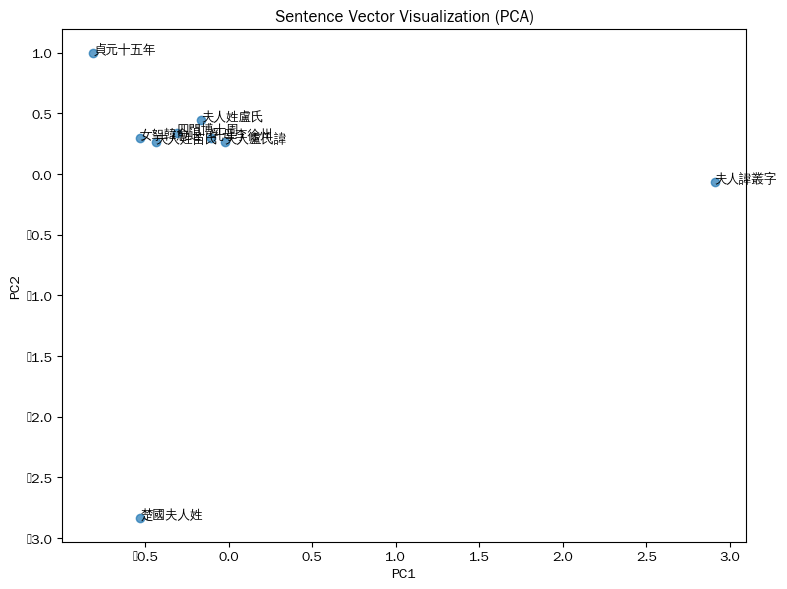

In [ ]:
# 1. 標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.7)

for i, sent in enumerate(sentences):
    plt.text(X_2d[i, 0], X_2d[i, 1], sent[:5], fontsize=9)

plt.title("Sentence Vector Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()

plt.savefig(
    "/content/drive/My Drive/SK_Hanyu_analysis_result.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

各主成分の寄与率:
PC1: 0.2632
PC2: 0.2547
PC3: 0.1928

累積寄与率:
PC1~PC1: 0.2632
PC1~PC2: 0.5178
PC1~PC3: 0.7106


/tmp/ipython-input-235550471.py:41: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) WenQuanYi Zen Hei.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) WenQuanYi Zen Hei.
  fig.canvas.print_figure(bytes_io, **kw)


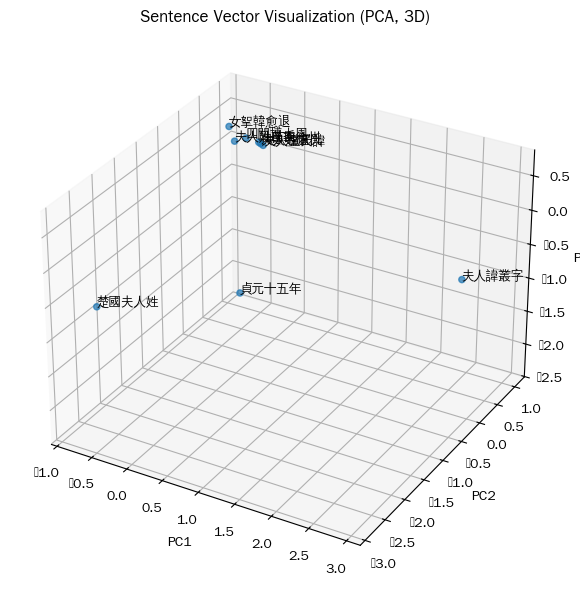

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3D描画用

# 1. PCAで3次元に圧縮
pca = PCA(n_components=3)
X_3d = pca.fit_transform(X)

# 1ｰ2. 寄与率と累積寄与率を計算
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_ratio = np.cumsum(explained_variance_ratio)

print("各主成分の寄与率:")
for i, ratio in enumerate(explained_variance_ratio, start=1):
    print(f"PC{i}: {ratio:.4f}")

print("\n累積寄与率:")
for i, cum_ratio in enumerate(cumulative_ratio, start=1):
    print(f"PC1~PC{i}: {cum_ratio:.4f}")

# 2. 3Dプロット作成
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# 3. 点をプロット
ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], alpha=0.7)

# 4. 文ラベルを表示
for i, sent in enumerate(sentences):
    ax.text(X_3d[i, 0], X_3d[i, 1], X_3d[i, 2], sent[:5], fontsize=9)

# 5. 軸ラベル・タイトル
ax.set_title("Sentence Vector Visualization (PCA, 3D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.tight_layout()

# 6. 保存
plt.savefig(
    "/content/drive/My Drive/SK_Hanyu_analysis_result_3D.png",
    dpi=300,
    bbox_inches="tight"
)

# 7. 表示
plt.show()


3次元へ削減した後の各文ベクトルのユークリッド距離を算出し、ヒートマップとして表示する。

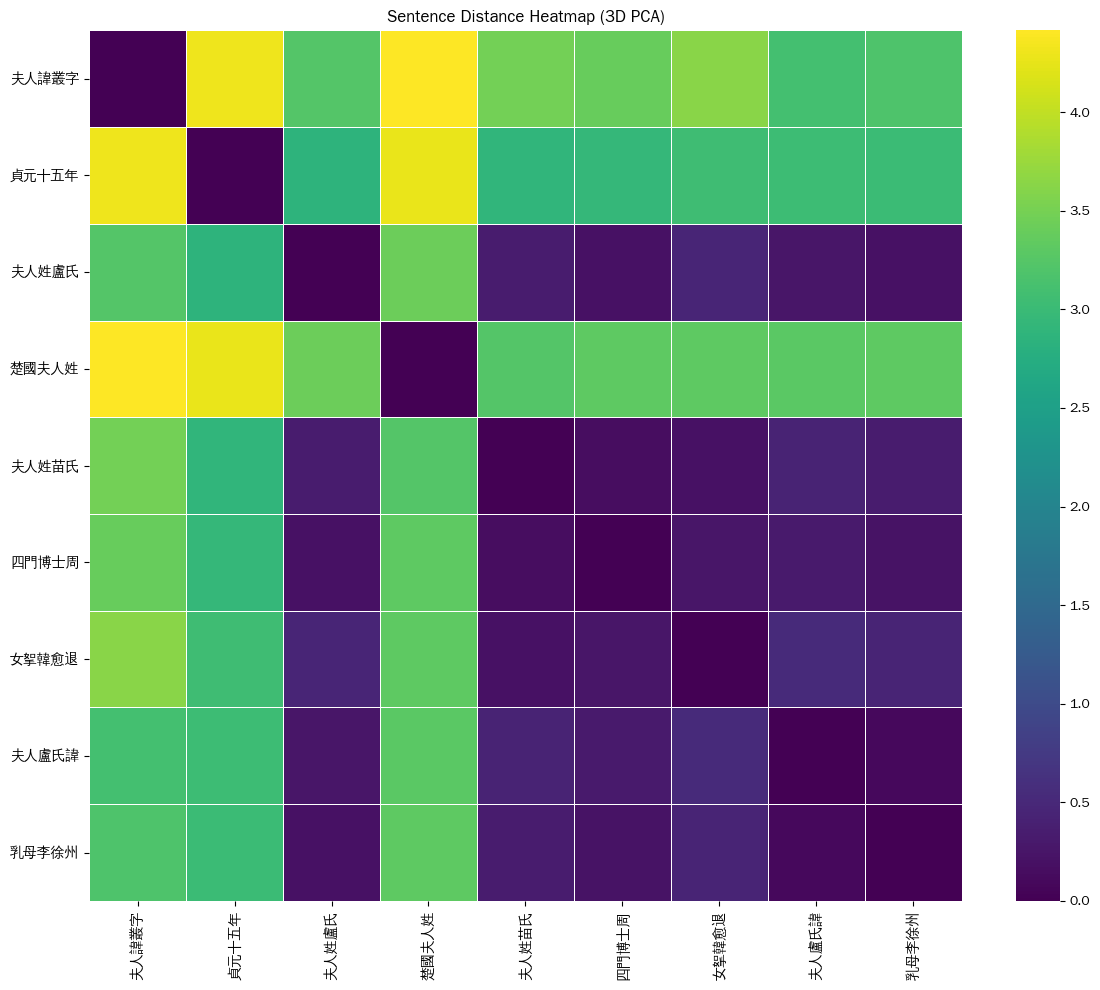

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist

# X_3d: PCAで3次元に圧縮した文ベクトル (n_samples, 3)
# sentences: 文のリスト

# 1. 距離行列を計算
D = cdist(X_3d, X_3d, metric='euclidean')  # D[i,j] = 文iと文jの距離

# 2-1. 文の冒頭5文字をラベルとして使用
short_labels = [s[:5] for s in sentences]

# 2ｰ2. DataFrame化
df_dist = pd.DataFrame(D, index=short_labels, columns=short_labels)

# 3. ヒートマップ描画
plt.figure(figsize=(12, 10))
sns.heatmap(df_dist, cmap='viridis', linewidths=0.5)
plt.title("Sentence Distance Heatmap (3D PCA)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

# 4. 保存（任意）
plt.savefig("/content/drive/My Drive/sentence_distance_heatmap.png", dpi=300, bbox_inches='tight')

plt.show()


さらに、文ベクトルについて語彙ごとに統計的代表ベクトルを作り、語彙ごとの意味的クラスタを可視化する。

※文脈ベクトルの扱いと単語ベクトルの扱いについて、コードを確認する必要がありそう

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) WenQuanYi Zen Hei.
  fig.canvas.print_figure(bytes_io, **kw)


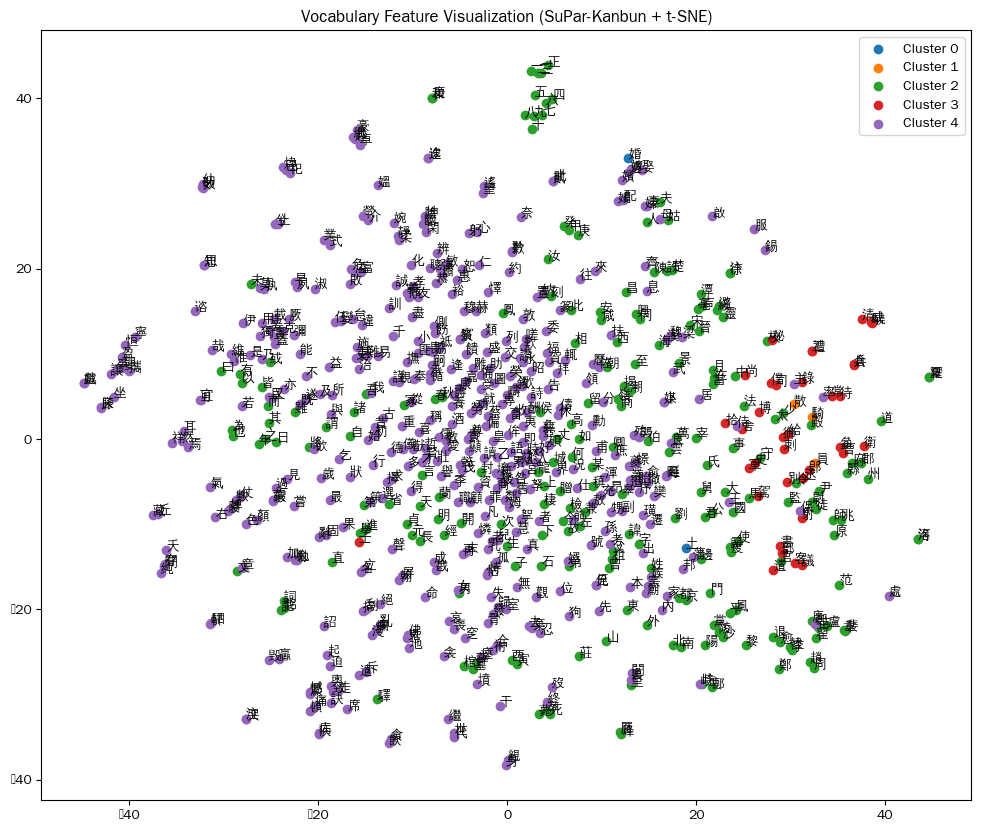

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
from collections import defaultdict
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# --- 1. CSVからトークン化済みデータを読み込む ---
df = pd.read_csv(input_file, header=None)  # 列番号は0から始まると仮定
tokenized_lines = df[0].tolist()  # 1列目にトークン列があると仮定

# 各文をトークンリストに変換（スペース区切りの場合）
sentences = [line.split(' ') for line in tokenized_lines]

# --- 3. 文脈ベクトルを取得 ---
word_vectors = defaultdict(list)
for token_list in sentences:
    sentence = ''.join(token_list)  # BERTは文字列入力
    inputs = tokenizer(sentence, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    embeddings = outputs.last_hidden_state[0]  # (seq_len, hidden_size)
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    # トークンごとに文脈ベクトルを集める
    for token, vec in zip(tokens, embeddings):
        if token not in ["[CLS]", "[SEP]"]:
            word_vectors[token].append(vec.numpy())

# --- 4. 語彙ベクトルの代表値（平均）を作成 ---
final_word_vectors = {word: np.mean(vecs, axis=0) for word, vecs in word_vectors.items()}

# --- 5. t-SNEで2次元に可視化 ---
words = list(final_word_vectors.keys())
vectors = np.array(list(final_word_vectors.values()))
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
X_2d = tsne.fit_transform(vectors)

# --- 6. クラスタリング（任意） ---
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(vectors)
labels = kmeans.labels_

# --- 7. 可視化 ---
plt.figure(figsize=(12, 10))
for cluster_id in range(n_clusters):
    idx = labels == cluster_id
    plt.scatter(X_2d[idx,0], X_2d[idx,1], label=f"Cluster {cluster_id}")

# 単語ラベルを表示
for i, word in enumerate(words):
    plt.text(X_2d[i,0], X_2d[i,1], word, fontsize=9)

plt.title("Vocabulary Feature Visualization (SuPar-Kanbun + t-SNE)")
plt.legend()
plt.show()

# --- 8. pngとして保存 ---
plt.savefig("/content/drive/My Drive/vocabulary_visualization.png", dpi=300, bbox_inches="tight")
